### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

---

## Airbnb Dataset 


---

### Data Loading

In [2]:
df = pd.read_excel('airbnb_listings.xlsx')
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaT,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaT,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaT,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,2008-06-26,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,2008-06-26,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [3]:
df.shape

(30478, 13)

There are 30478 rows and 13 columns in the dataset.

---
### Hypothesis
---

### Airbnb listings that offer more privacy (like entire homes), are in popular areas (like Manhattan), are managed by experienced hosts, and have more beds tend to have higher prices.

---
### Data Cleaning and Preparation
---

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Host Id                     30478 non-null  int64         
 1   Host Since                  30475 non-null  datetime64[ns]
 2   Name                        30478 non-null  object        
 3   Neighbourhood               30478 non-null  object        
 4   Property Type               30475 non-null  object        
 5   Review Scores Rating (bin)  22155 non-null  float64       
 6   Room Type                   30478 non-null  object        
 7   Zipcode                     30344 non-null  float64       
 8   Beds                        30393 non-null  float64       
 9   Number of Records           30478 non-null  int64         
 10  Number Of Reviews           30478 non-null  int64         
 11  Price                       30478 non-null  int64     

#### Dropping useless columns


In [5]:
df['Number of Records'].value_counts()

Number of Records
1    30478
Name: count, dtype: int64

In [6]:
df = df.drop(['Host Id', 'Name', 'Number of Records', 'Review Scores Rating (bin)', 'Property Type', 'Review Scores Rating', 'Zipcode','Number Of Reviews'], axis=1)
df.head(2)

,Host Since,Neighbourhood,Room Type,Beds,Price
0,NaT,Brooklyn,Entire home/apt,1.0,145
1,NaT,Brooklyn,Private room,1.0,37


The following columns were dropped as they do not contribute meaningful insights for the analysis:
- Host Id: a unique identifier that doesn’t affect any trends or relationships.
- Name: mostly unique text (listing titles) that isn’t useful for numerical or categorical analysis.
- Number of Records: contains the same value for all rows, providing no variability or information.
- Review Scores Rating (bin): a duplicate of the main review rating column in binned form, which could create redundancy.
- Property Type: not relevant to the hypothesis on privacy, neighborhood, and host experience.
- Review Scores Rating: not part of the current hypothesis and not needed for analysis.
- Zipcode: granular location data not required; neighborhoods are sufficient.

In [7]:
df.describe()

,Host Since,Beds,Price
count,30475,30393.000000,30478.000000
mean,2013-06-29 17:56:15.317473280,1.530089,163.589737
min,2008-06-26 00:00:00,0.000000,10.000000
25%,2012-06-21 00:00:00,1.000000,80.000000
50%,2013-09-01 00:00:00,1.000000,125.000000
75%,2014-09-12 00:00:00,2.000000,195.000000
max,2015-08-31 00:00:00,16.000000,10000.000000
std,NaN,1.015359,197.785454


### Summary of Statistical Description

- The dataset contains 30,478 Airbnb listings with various property and pricing details.  
- The **average price** is around 164 Dollars, while the median is 125 Dollars, showing a few very expensive outliers.  
- Most listings have **1–2 beds**, suggesting small apartments or private rooms dominate the market.  
- Most listings have very few or no reviews, while a small number are highly popular with hundreds, showing that reviews are unevenly distributed.  
- Host activity spans from **2008 to 2015**, showing both experienced and newer hosts.  

Overall, Airbnb listings show high ratings, moderate prices, and a few extreme outliers that may impact analysis.

### Missing Values

In [8]:
df.isnull().sum() 

Host Since         3
Neighbourhood      0
Room Type          0
Beds              85
Price              0
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

Host Since        0.009843
Neighbourhood     0.000000
Room Type         0.000000
Beds              0.278890
Price             0.000000
dtype: float64

In [10]:
df = df.dropna(subset=['Host Since'])

In [11]:
df['Beds'] = df['Beds'].fillna(df['Beds'].median())

In [12]:
df.isnull().sum()

Host Since        0
Neighbourhood     0
Room Type         0
Beds              0
Price             0
dtype: int64

### Missing Value Treatment

Host Since and Property Type: Dropped rows with missing entries (less than 1%).    
Beds: Replaced missing values with median to avoid skew from extreme values.  
All other columns contained no missing values.

### Checking Datatypes

In [13]:
df.dtypes

Host Since        datetime64[ns]
Neighbourhood             object
Room Type                 object
Beds                     float64
Price                      int64
dtype: object

No changes required.

### Checking Duplicates

In [14]:
df.duplicated().sum()

np.int64(2079)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

---
### Feature Engineering
---

In [17]:
df['Host_Experience_Years'] = datetime.now().year - df['Host Since'].dt.year

In [18]:
df.head(5)

,Host Since,Neighbourhood,Room Type,Beds,Price,Host_Experience_Years
3,2008-06-26,Manhattan,Entire home/apt,3.0,199,17
4,2008-06-26,Manhattan,Private room,3.0,549,17
5,2008-07-25,Brooklyn,Entire home/apt,1.0,149,17
6,2008-08-12,Manhattan,Entire home/apt,1.0,250,17
7,2008-08-15,Brooklyn,Private room,1.0,90,17


Created new columns:  
- Host Experience Years: Shows how long the host has been on Airbnb to see if experience affects price or ratings.  

---
### Data Ink Ratio
---

In [39]:
def calculate_ratio(ax):
   
    data_elements = len(ax.patches) + len(ax.lines) + len(ax.collections)

    text_elements = len(ax.texts) * 0.3      
    tick_elements = (len(ax.get_xticks()) + len(ax.get_yticks())) * 0.2
    grid_elements = (len(ax.get_xgridlines()) + len(ax.get_ygridlines())) * 0.1
    spine_elements = len(ax.spines) * 0.1

    total_elements = (
        data_elements + text_elements + tick_elements + grid_elements + spine_elements
    )
    
    if total_elements == 0:
        return None

    ratio = round(data_elements / total_elements, 3)
    print(f"Data-to-Ink Ratio (estimated): {ratio}")
    return ratio

---
### Univariate Analysis
---

In [19]:
numeric_cols = df.select_dtypes(include=['int64', 'float64','int32']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [20]:
numeric_cols

Index(['Beds', 'Price', 'Host_Experience_Years'], dtype='object')

In [21]:
categorical_cols

Index(['Neighbourhood ', 'Room Type'], dtype='object')

### Distribution of Numerical Columns

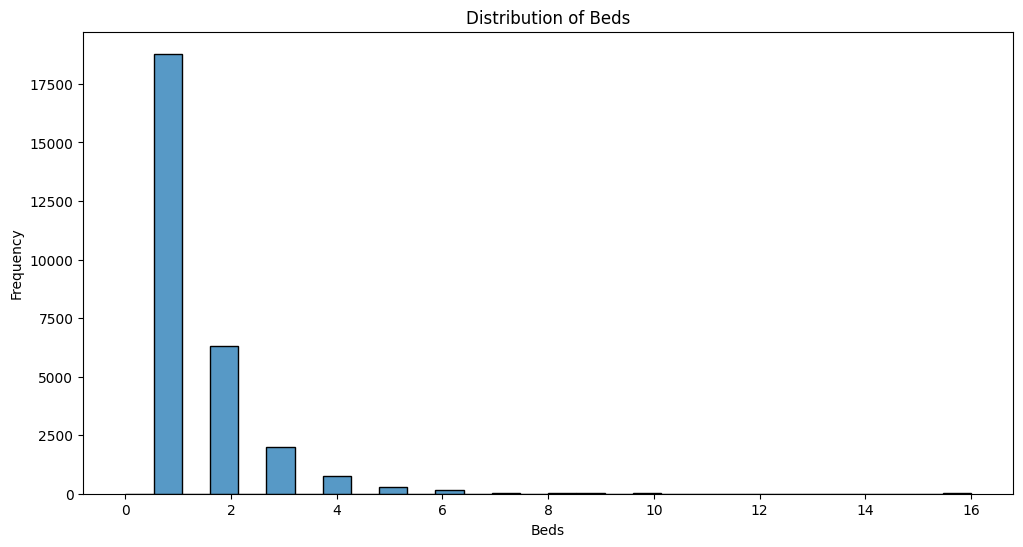



Data-to-Ink Ratio (estimated): 0.824






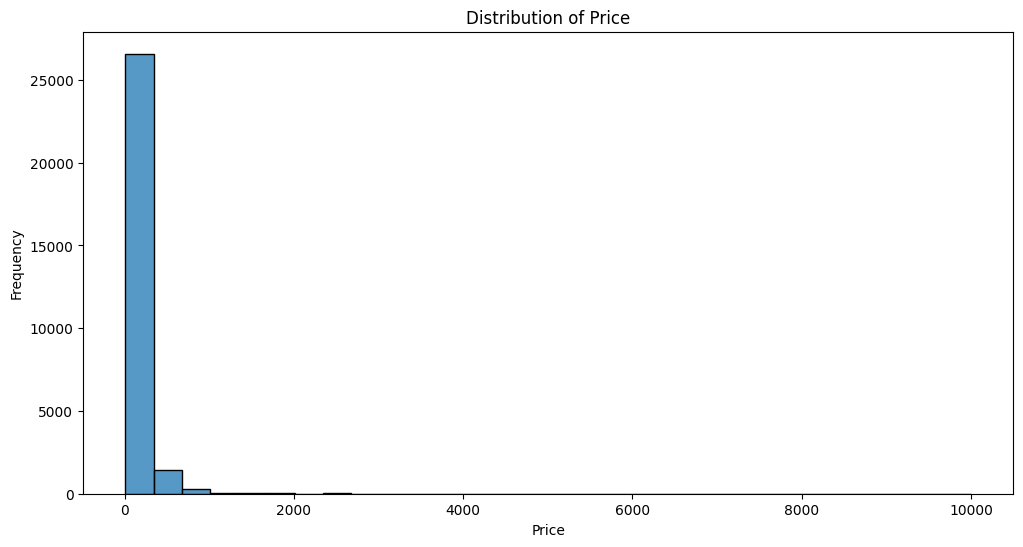



Data-to-Ink Ratio (estimated): 0.86






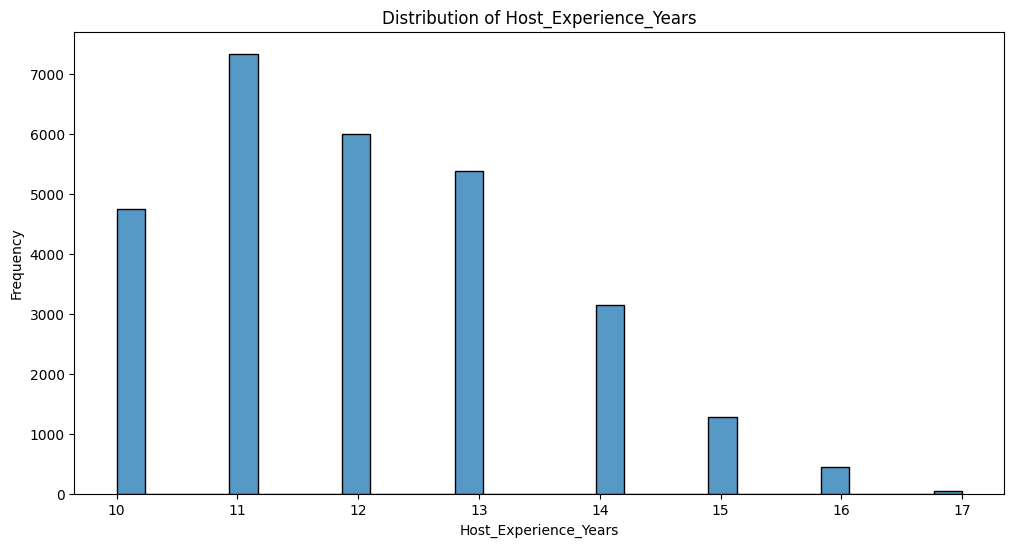



Data-to-Ink Ratio (estimated): 0.831






In [65]:
for col in numeric_cols:
    plt.figure(figsize=(12, 6))
    ax=sns.histplot(df[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    print("\n")
    calculate_ratio(ax)
    print("\n\n\n")

### Univariate Analysis Insights

Beds: Most listings have 1 or 2 beds, with very few listings having more than 3 beds.  
Price: Most listings are priced under $500, with a few luxury listings reaching very high prices.  
Host_Experience_Years: Most hosts have between 10 and 14 years of experience. The biggest chunk of hosts falls right around 11, 12, and 13 years, with 11 being the highest peak. The number of hosts drops off quickly after 14 years.


Graphical Integrity: The bars correctly show how often values occur, and the y-axis starts at zero, so the chart is honest and not misleading.

Clear Labeling: Each histogram has clear titles and labeled axes, making it easy to read and understand.

Data-Ink Ratio: The design is clean, using only what’s needed to show the data without extra lines or clutter.

Avoiding Chartjunk: The chart avoids 3D effects or fancy decorations, keeping the focus on the data itself.

Binning Choice: The same number of bins works well for an overview, but different variables might need different bin sizes for more detail.

### Detecting Outliers 

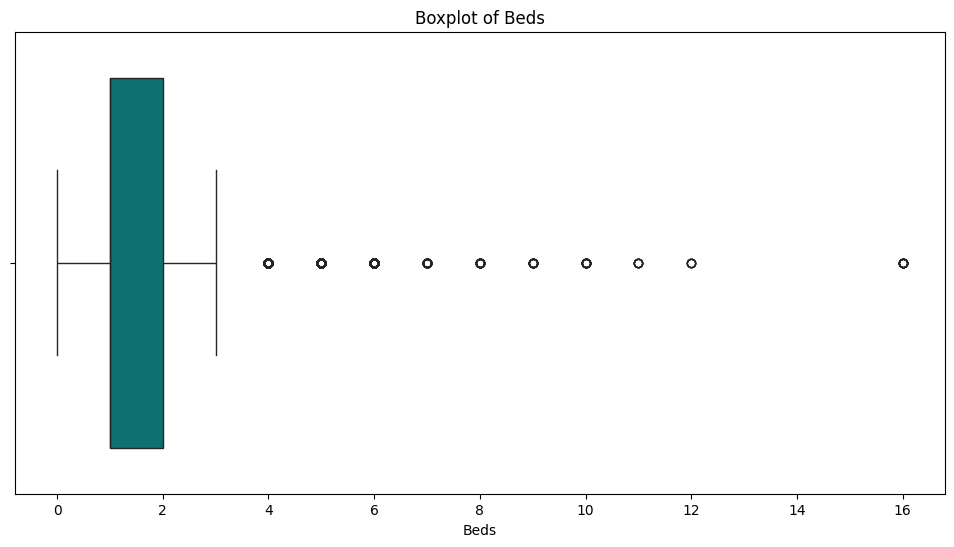



Data-to-Ink Ratio (estimated): 0.636






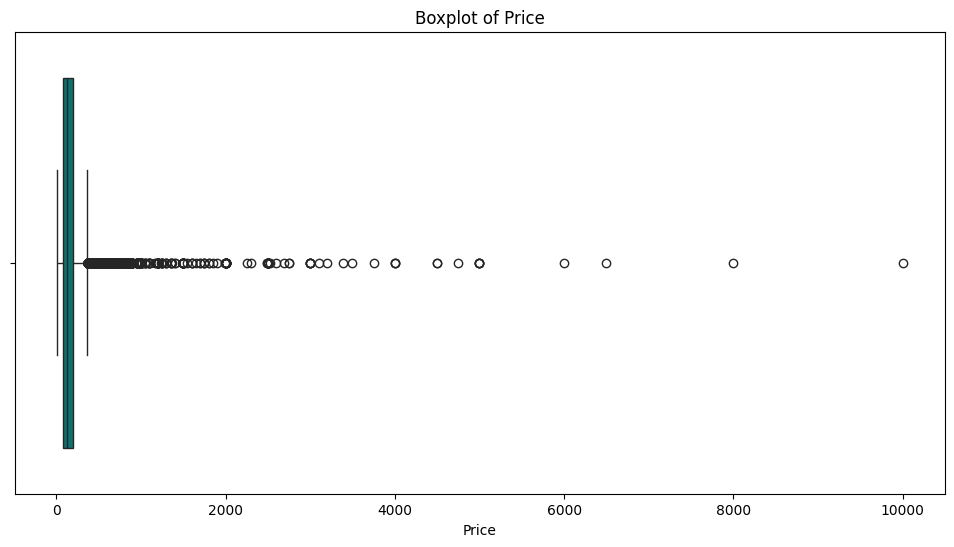



Data-to-Ink Ratio (estimated): 0.693






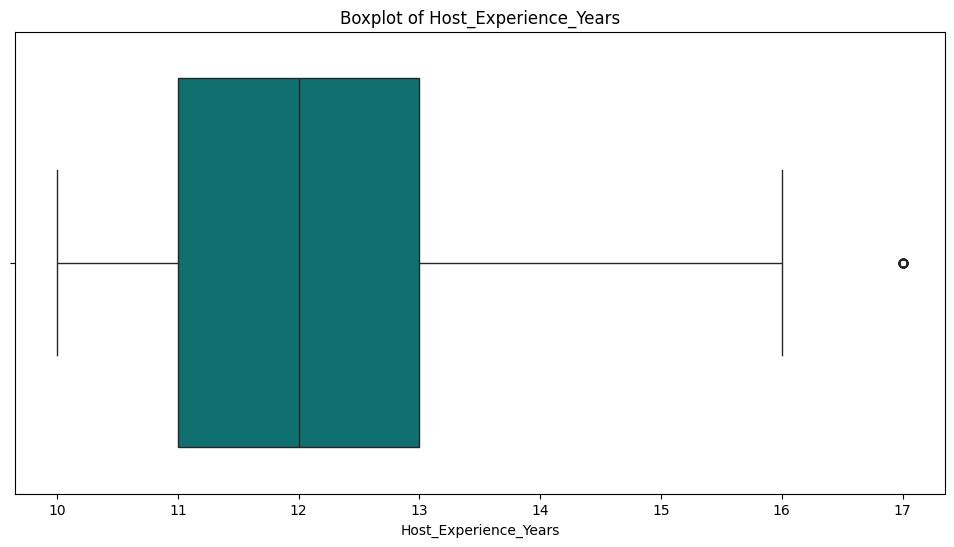



Data-to-Ink Ratio (estimated): 0.654






In [52]:
for col in numeric_cols:
    plt.figure(figsize=(12, 6))
    ax=sns.boxplot(x=df[col], color='teal')
    plt.title(f"Boxplot of {col}")
    plt.show()
    print("\n")
    calculate_ratio(ax)
    print("\n\n\n")

### Boxplot Insights

Price: Most listings are budget-friendly with a few extremely expensive outliers.  
Host_Experience_Years (Boxplot): The middle 50% of hosts (the box) have experience between about 11 and 13 years. The line inside the box shows the median is slightly below 12 years. The data has a high outlier around 17 years, meaning there's one host much more experienced than everyone else.
Beds: Typical listings have 1–2 beds, while a few listings have many more.  

Graphical Integrity: The boxplot honestly shows the spread and outliers in the data, with whiskers and quartiles drawn to scale so nothing looks exaggerated.

Clear Labeling: Each plot includes a simple title and clear axis labels, making it easy to understand what variable is being shown.

Data-Ink Ratio: The design uses very little ink just a box, whiskers, and a few lines while still showing all the key details like median and outliers.

Avoiding Chartjunk: The plot avoids unnecessary colors, patterns, or 3D effects, keeping the viewer’s attention on the actual data

Handling Outliers: Handled outliers in the following numerical columns:

- Price: Applied a log transformation to reduce the effect of very expensive listings.   

In [24]:
df['Log_Price'] = np.log1p(df['Price'])  
df[['Price', 'Log_Price']].head()

,Price,Log_Price
3,199,5.298317
4,549,6.309918
5,149,5.010635
6,250,5.525453
7,90,4.510860


### Distribution of Categorical Columns

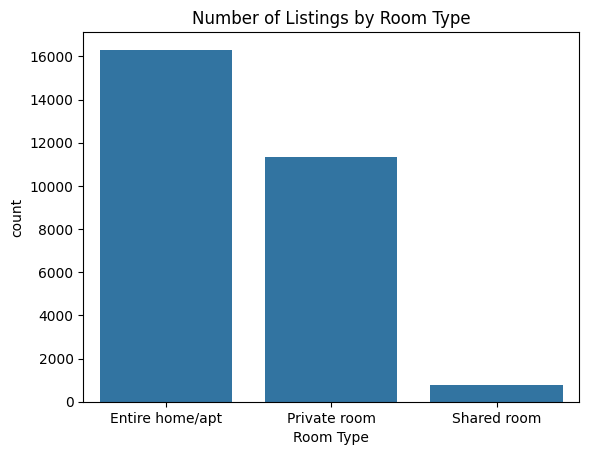



Data-to-Ink Ratio (estimated): 0.411


0.411

In [53]:
ax=sns.countplot(x='Room Type', data=df)
plt.title('Number of Listings by Room Type')
plt.show()
print("\n")
calculate_ratio(ax)

Most Airbnb listings are Entire homes or apartments, followed by Private rooms, while Shared rooms are very rare. This shows that the market mainly favors fully private or semi-private accommodations.

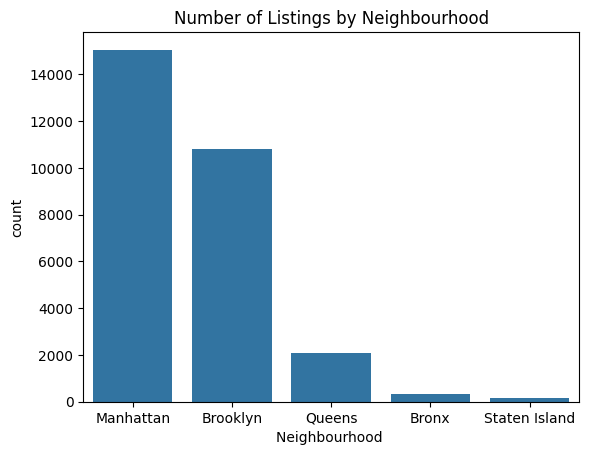



Data-to-Ink Ratio (estimated): 0.521


0.521

In [54]:
ax=sns.countplot(x='Neighbourhood ', data=df)
plt.title('Number of Listings by Neighbourhood')
plt.show()
print("\n")
calculate_ratio(ax)

Most Airbnb listings are concentrated in Manhattan and Brooklyn, with Manhattan having the highest number, followed by Brooklyn. Listings in Queens, the Bronx, and Staten Island are much fewer.

Graphical Integrity: The count plots honestly represent the data, with bar heights that correctly reflect the actual counts and axes starting at zero to avoid distortion.

Clear Labeling: Each plot includes clear titles and axis labels, making it easy to understand what is being compared.

Data-Ink Ratio: The design is simple and clean, using only what’s necessary to display the data without extra lines, borders, or clutter.

Avoiding Chartjunk: The plots avoid 3D effects, bright colors, or unnecessary decorations, keeping the focus entirely on the data.

Sorting (Minor Issue): The categories are not always sorted by value, which can make comparisons slower sorting them could improve clarity.

---
### Bivariate Analysis
---

### Numerical vs Numerical

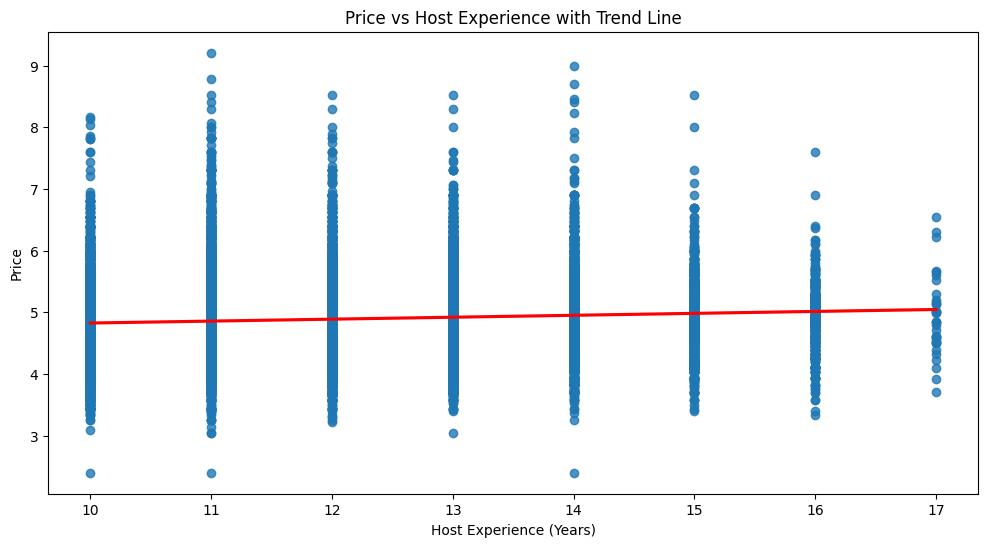



Data-to-Ink Ratio (estimated): 0.33


0.33

In [55]:
plt.figure(figsize=(12, 6))
ax=sns.regplot(data=df, x='Host_Experience_Years', y='Log_Price',line_kws={'color':'red'})
plt.title('Price vs Host Experience with Trend Line')
plt.xlabel('Host Experience (Years)')
plt.ylabel('Price')
plt.show()
print("\n")
calculate_ratio(ax)

The scatter plot shows that host experience doesn’t really affect the listing price, which goes against what was expected in the hypothesis. The trend line is almost flat, and most prices stay low. A few listings are very expensive, but these are rare and don’t show a clear pattern. So, host experience alone doesn’t determine price.

Graphical Integrity: Each point is placed accurately based on its host experience and price, honestly representing the data.

Clear Labeling: The x-axis shows “Host Experience (Years)” and the y-axis shows “Price.” The title is descriptive, making it easy to understand what the plot shows.

Show the Data: The plot clearly displays how prices are distributed across different levels of host experience. The points reveal concentrations and variation, while the red trend line helps summarize the overall pattern.

Data-Ink Ratio: The plot is simple and clean. Points and the trend line are essential for showing the data. Gridlines and other non-data ink are minimal, keeping the focus on the data itself.

Context: Both axes use appropriate scales for the data, preventing distortion and making it easy to interpret the relationship.

Avoiding Chartjunk: The scatter plot uses a straightforward 2D design with no unnecessary decorations or 3D effects, keeping it clean and easy to read.

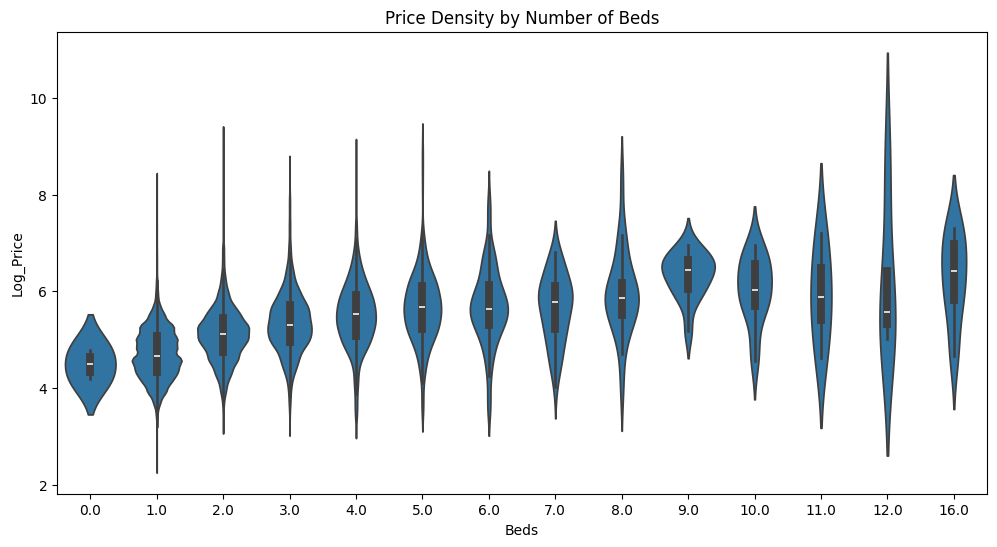

In [57]:
ax = plt.figure(figsize=(12, 6))
sns.violinplot(x='Beds', y='Log_Price', data=df)
plt.title('Price Density by Number of Beds')
plt.show()

The violin plot shows that the number of beds does not strongly predict the typical price of a listing. Most listings, regardless of bed count, are concentrated at lower prices, and while a few smaller listings have extremely high outliers, the median price remains fairly consistent across bed counts.


Graphical Integrity: The width of the violin reflects how common each price is, and the central line/box shows the median and quartiles. This accurately represents the data.

Clear Labeling: The x-axis shows the number of beds, and the y-axis shows Log_Price. The title and labels are clear, so it is easy to understand what the plot shows.

Show Data Variation: The violin shape shows the full distribution for each bed category, including peaks, spread, and variation. The box plot inside highlights the median and quartiles, giving extra information at a glance.

Data-Ink Ratio: Most of the ink is used to show data. The filled shapes and lines are all necessary to understand the distribution and statistics.

Avoiding Chartjunk: The plot is fully 2D and clean, with no 3D effects or unnecessary decoration, making it easy to read.


---
### Categorical vs Numerical
---

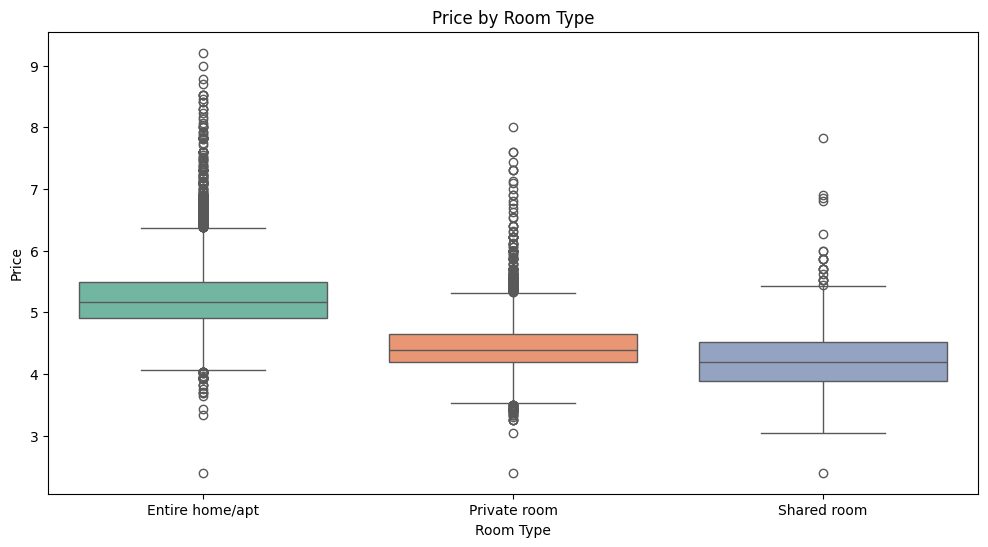



Data-to-Ink Ratio (estimated): 0.84


0.84

In [58]:
plt.figure(figsize=(12, 6))
ax=sns.boxplot(data=df, x='Room Type', y='Log_Price', palette='Set2')
plt.title('Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()
print("\n")
calculate_ratio(ax)

The box plot shows that entire homes or apartments are the most expensive, private rooms are moderately priced, and shared rooms are the cheapest. This supports the hypothesis that listings with more privacy tend to have higher prices.

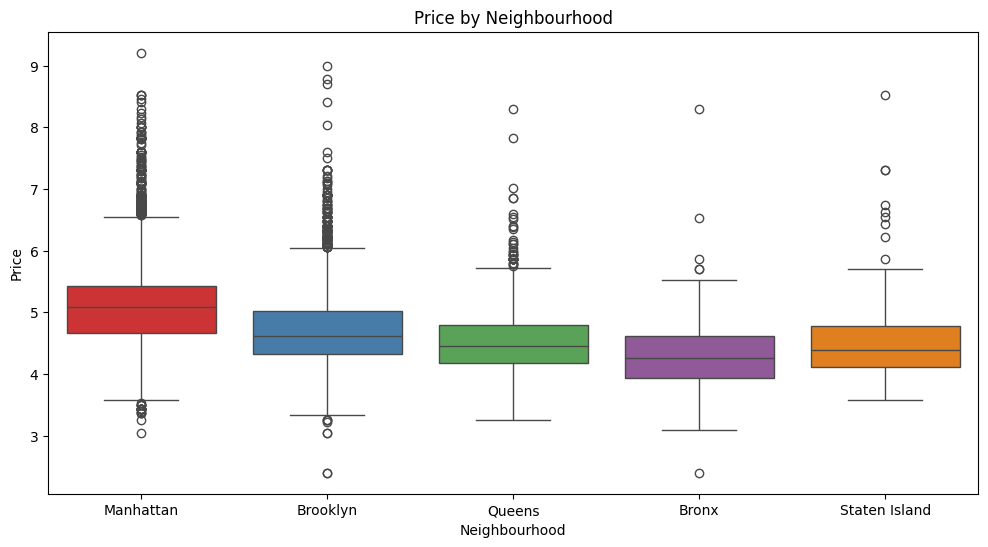



Data-to-Ink Ratio (estimated): 0.884


0.884

In [59]:
plt.figure(figsize=(12, 6))
ax=sns.boxplot(data=df, x='Neighbourhood ', y='Log_Price', palette='Set1')
plt.title('Price by Neighbourhood')
plt.xlabel('Neighbourhood')
plt.ylabel('Price')
plt.show()
print("\n")
calculate_ratio(ax)

The box plot shows that Manhattan listings are the priciest and most varied, while the Bronx has the lowest prices. Other neighborhoods are in between, and all areas have a few very expensive outliers. This supports the hypothesis that listings in popular areas tend to cost more.

#### Graphical Integrity: The boxplots honestly shows the spread and outliers in the data, with whiskers and quartiles drawn to scale so nothing looks exaggerated.
#### Clear Labeling: Each plot includes a simple title and clear axis labels, making it easy to understand what variable is being shown.
#### Data-Ink Ratio: The design uses very little ink just a box, whiskers, and a few lines while still showing all the key details like median and outliers.
#### Avoiding Chartjunk: The plot avoids unnecessary colors, patterns, or 3D effects, keeping the viewer’s attention on the actual data


---
### Categorical vs Categorical
---

In [29]:
neigh_room_counts = pd.crosstab(df['Neighbourhood '], df['Room Type'])
neigh_room_counts

Room Type,Entire home/apt,Private room,Shared room
Neighbourhood,,,
Bronx,88,209,24
Brooklyn,5508,5052,227
Manhattan,9761,4875,413
Queens,887,1126,88
Staten Island,62,73,3


<Figure size 1200x600 with 0 Axes>

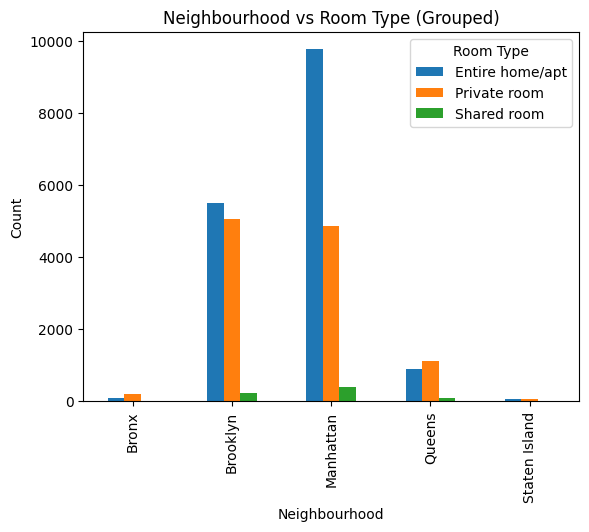



Data-to-Ink Ratio (estimated): 0.789


0.789

In [61]:
plt.figure(figsize=(12, 6))
ax=neigh_room_counts.plot(kind='bar', stacked=False)
plt.title('Neighbourhood vs Room Type (Grouped)')
plt.xlabel('Neighbourhood')
plt.ylabel('Count')
plt.show()
print("\n")
calculate_ratio(ax)

Most listings in Manhattan and Brooklyn are entire homes or private rooms, while shared rooms are rare everywhere. The Bronx, Queens, and Staten Island have far fewer listings overall. This supports the hypothesis because more private listings are concentrated in popular areas, which also tend to have higher prices.

Graphical Integrity: The count plots honestly represent the data, with bar heights that correctly reflect the actual counts and axes starting at zero to avoid distortion.

Clear Labeling: Each plot includes clear titles and axis labels, making it easy to understand what is being compared.

Data-Ink Ratio: The design is simple and clean, using only what’s necessary to display the data without extra lines, borders, or clutter.

Avoiding Chartjunk: The plots avoid 3D effects, bright colors, or unnecessary decorations, keeping the focus entirely on the data.

Sorting (Minor Issue): The categories are not always sorted by value, which can make comparisons slower sorting them could improve clarity.

---
### Multivariate Analysis
---

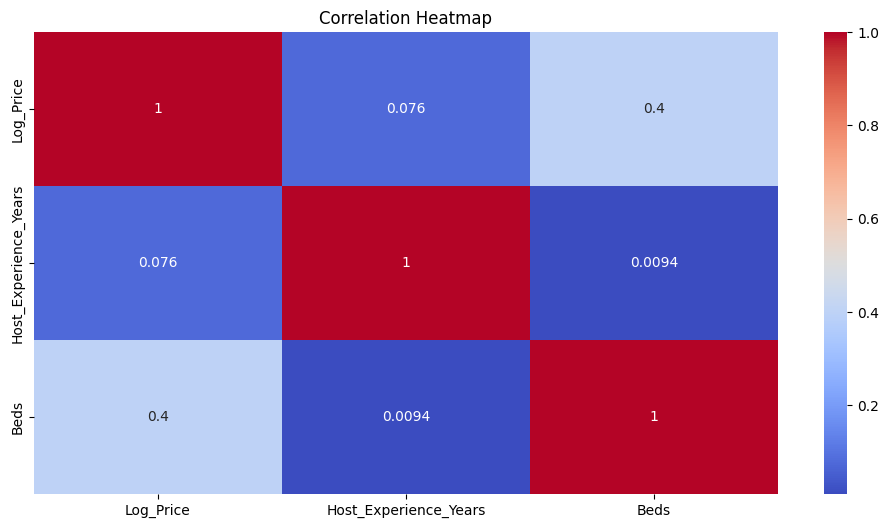

In [31]:
plt.figure(figsize=(12, 6))
sns.heatmap(df[['Log_Price', 'Host_Experience_Years','Beds']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Correlation Heatmap

Created a correlation heatmap to explore relationships between numerical columns.

### Heatmap Insights

- Price vs Host Experience: Very weak correlation (0.08), confirming that host experience does not affect price.
- Price vs Beds: Moderate positive correlation (0.40), showing that listings with more beds tend to have slightly higher prices, but the effect is not very strong.
- Host Experience vs Beds: Almost no correlation (0.01), meaning host experience and listing size are unrelated.

Conclusion: Among numeric variables, only the number of beds has a modest effect on price, while host experience is irrelevant.

Graphical Integrity The heatmap accurately represents correlations with both color intensity and exact numbers, so viewers can trust the visual reflects the true data.

Clear Labeling Row and column labels are clear, the title is descriptive, and the colorbar shows the correlation scale, making it easy to interpret.

Data Variation Color changes only reflect actual differences in correlation values, so the design does not introduce misleading variation.

Data-Ink Ratio Most of the ink is used for data: the colored cells and numbers convey information, and the background is clean with minimal extra lines.

Avoiding Chartjunk The plot is strictly 2D with no unnecessary decorations, maintaining focus on the data.


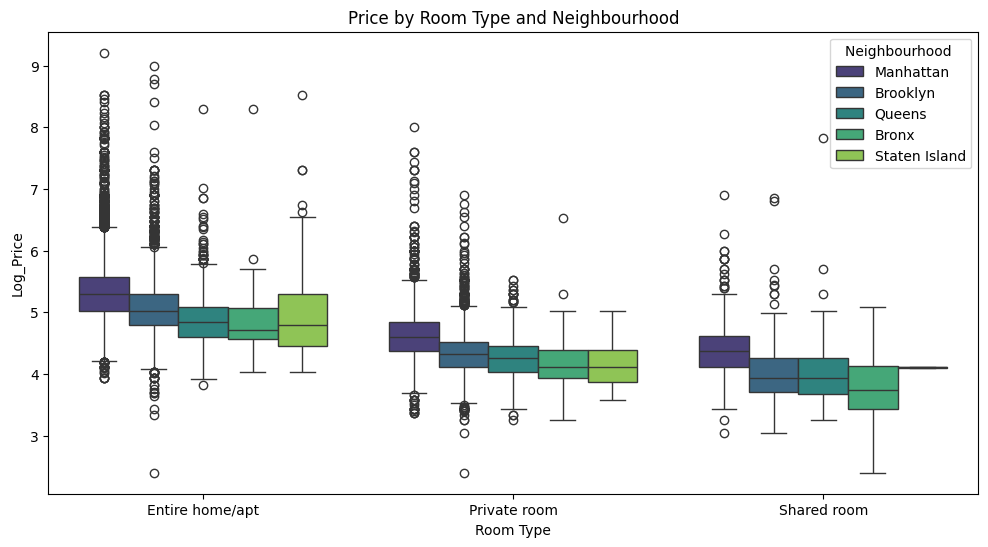



Data-to-Ink Ratio (estimated): 0.965


0.965

In [60]:
plt.figure(figsize=(12, 6))
ax=sns.boxplot(data=df, x='Room Type', y='Log_Price', hue='Neighbourhood ',palette='viridis' )
plt.title('Price by Room Type and Neighbourhood')
plt.show()
print("\n")
calculate_ratio(ax)

### Log Price by Room Type and Neighbourhood

Made a log-transformed box plot to see how price changes based on room type (privacy) and neighbourhood (location). The log helps handle the really high-priced listings.

### Plot Insights

- Room Type: Entire homes cost the most, private rooms are in the middle, and shared rooms are cheapest. This supports our hypothesis that more private places are pricier.
- Neighbourhood: Manhattan listings are the most expensive, while the Bronx, Queens, and Staten Island are cheaper. This supports the part of our hypothesis about popular areas having higher prices.
- Room Type + Neighbourhood: Entire homes in Manhattan are the priciest, and shared rooms in outer boroughs are cheapest. Shows that privacy and location together affect price.
- Price Range: Manhattan entire homes have the widest range of prices, while outer boroughs are more consistent.

Conclusion: Both privacy and location strongly affect price, while other factors like host experience don’t matter much.

# Hypothesis Summary

### Hypothesis: Airbnb listings that offer more privacy (like entire homes), are in popular areas (like Manhattan), and are managed by experienced hosts tend to have higher prices.

#### Findings:

- Privacy (Room Type): Supported. Entire homes are consistently more expensive than private or shared rooms.
- Location (Neighbourhood): Supported. Listings in Manhattan are the priciest across all room types.
- Host Experience: Not supported. Host experience has almost no effect on price.
- Number of Beds: Not supported. The number of beds does not consistently affect price; larger listings are not necessarily more expensive.

Conclusion: Privacy and location clearly influence price, confirming most of our hypothesis, while host experience and number of beds do not seem to matter.